# Titanic Survival Prediction using XGBoost

This project aims to predict passenger survival on the Titanic using machine learning and feature engineering techniques.

The workflow includes:

* Data cleaning and preprocessing
* Handling missing values
* Feature engineering using passenger titles and family size information
* Categorical feature encoding
* XGBoost model training
* Feature importance analysis
* Hyperparameter tuning to reduce overfitting and improve generalization

Several engineered features were investigated, including title extraction from passenger names, rare title grouping, family size categorization, and cabin-related features. The final model was optimized using XGBoost and achieved a test accuracy of approximately **83.71%**.

This notebook documents the complete process from raw data preprocessing to model evaluation and performance analysis.


---

## Importing Dependencies

The required libraries for data manipulation, visualization, model training, and evaluation are imported in this section.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

## Data Collection and Loading

The Titanic training and test datasets are loaded into Pandas DataFrames. The training dataset is used to build and evaluate the model, while the test dataset is reserved for generating Kaggle competition submissions.

In [2]:
df_train=pd.read_csv('/kaggle/input/datasets/abeermalviya/titanic-xgboost/train.csv')
df_test=pd.read_csv('/kaggle/input/datasets/abeermalviya/titanic-xgboost/test.csv')

df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis

In this section, the structure and statistical properties of the dataset are examined to better understand the available features and identify potential preprocessing requirements.

### Dataset Dimensions

The shape of the dataset is inspected to determine the number of observations and features available for analysis.

In [3]:
df_train.shape

(891, 12)

### Statistical Summary

Summary statistics of the numerical features are examined to understand their distribution, central tendency, and variability.

In [4]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Missing Value Analysis

The dataset is examined for missing values to identify features that require preprocessing before model training.

In [5]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Handling Missing Values

Missing values in the dataset are addressed before feature engineering and model training. Missing ages are imputed using the mean age, the Cabin feature is removed due to a large number of missing values, and rows with missing Embarked values are removed.

In [6]:
# Fill missing ages with mean age
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].mean())

# drop cabim
df_train.drop(['Cabin'],axis=1,inplace=True)

# Remove rows with missing embarked values
df_train.dropna(subset=['Embarked'],inplace=True)

### Removing Uninformative Features

The Ticket feature was removed from the dataset. Ticket numbers are primarily identifiers and do not provide a clear numerical or categorical relationship with passenger survival. Removing such features can help simplify the model and reduce unnecessary complexity.

In [7]:
df_train.drop(['Ticket'], axis=1, inplace=True)
df_train.drop('PassengerId', axis=1, inplace=True)

## Feature Engineering

### Family Size Feature

A new feature called Family_Size is created by combining the number of siblings/spouses (SibSp), parents/children (Parch), and the passenger themselves. This feature is used to investigate whether family size influences survival probability.

In [8]:
df_train['Family_Size']=(
    1+
    df_train['SibSp']+
    df_train['Parch']
)

### Analyzing the Relationship Between Family Size and Survival

To determine whether family size influences survival probability, the survival rate for each family size category is calculated. This analysis helps identify patterns that can be used to create more informative features.

In [9]:
print(
    df_train.groupby('Family_Size')['Survived']
    .agg(['count', 'sum', 'mean'])
)

             count  sum      mean
Family_Size                      
1              535  161  0.300935
2              161   89  0.552795
3              102   59  0.578431
4               29   21  0.724138
5               15    3  0.200000
6               22    3  0.136364
7               12    4  0.333333
8                6    0  0.000000
11               7    0  0.000000


### Family Size Categorization

Based on the observed survival rates, family sizes were grouped into broader categories. Passengers traveling alone, with small families, and with large families exhibited different survival patterns, making this feature potentially more informative than the raw family size values.

In [10]:
df_train['Family_Size']=df_train['Family_Size'].replace(1, 'is_alone')

In [11]:
df_train['Family_Size']=df_train['Family_Size'].replace([2,3,4], 'small_family')

In [12]:
df_train['Family_Size']=df_train['Family_Size'].replace([5,6,7,8,11], 'large_family')

### One-Hot Encoding of Family Size Categories

Machine learning models require numerical inputs. Therefore, the categorical Family_Size groups are converted into binary indicator variables using one-hot encoding.

In [13]:
Family_Size_Dummies=pd.get_dummies(df_train['Family_Size'],prefix='Family_Size')

df_train=pd.concat([df_train,Family_Size_Dummies],axis=1)

The original Family_Size categorical feature is removed after one-hot encoding to avoid redundancy.

In [14]:
df_train.drop(['Family_Size'],axis=1,inplace=True)

### Converting Encoded Features to Numerical Format

The one-hot encoded Family Size features are converted from boolean values to integer values (0 and 1) to ensure compatibility with machine learning models.

In [15]:
df_train[['Family_Size_is_alone','Family_Size_large_family','Family_Size_small_family']]=(
    df_train[['Family_Size_is_alone','Family_Size_large_family','Family_Size_small_family']].astype(int)
)

### Verifying Missing Value Treatment

The dataset is checked again to confirm that all missing values have been successfully handled.

In [16]:
df_train.isnull().sum()

Survived                    0
Pclass                      0
Name                        0
Sex                         0
Age                         0
SibSp                       0
Parch                       0
Fare                        0
Embarked                    0
Family_Size_is_alone        0
Family_Size_large_family    0
Family_Size_small_family    0
dtype: int64

### Encoding the Sex Feature

The Sex feature is converted into a binary numerical format, where male passengers are represented by 1 and female passengers by 0.

In [17]:
# Encode Sex column
df_train['Sex'] = df_train['Sex'].map({
    'male': 1,
    'female': 0
})

### One-Hot Encoding the Embarked Feature

The Embarked feature represents the passenger's port of embarkation. Since it is a categorical variable with multiple categories, one-hot encoding is used to create separate binary features for each embarkation port.

In [18]:
embarked_dummies=pd.get_dummies(df_train['Embarked'],prefix='Embarked')

df_train=pd.concat([df_train, embarked_dummies], axis=1)

df_train.drop('Embarked', axis=1, inplace=True)

### Converting Encoded Features to Integer Format

The one-hot encoded embarkation features are converted from boolean values to integer values (0 and 1) for consistency across the dataset.

In [19]:
df_train[['Embarked_C', 'Embarked_Q', 'Embarked_S']] = (
    df_train[['Embarked_C', 'Embarked_Q', 'Embarked_S']].astype(int)
)

### Title Extraction from Passenger Names

Passenger names contain social titles such as Mr, Mrs, Miss, and Master, which may provide useful information about age, gender, social status, and family role. These titles are extracted from the Name feature and analyzed as potential predictors of survival.

In [20]:
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_58/1220814546.py:1: SyntaxWarning: invalid escape sequence '\.'
  df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [21]:
df_train['Title'].value_counts()

Title
Mr          517
Miss        181
Mrs         124
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

### Grouping Rare Titles

Many extracted titles appear only a few times in the dataset. To reduce sparsity and improve model generalization, infrequent titles are grouped into a single Rare category.

In [22]:
rare_titles = [
    'Dr','Rev','Col','Mlle','Major',
    'Ms','Mme','Don','Lady',
    'Sir','Capt','Countess','Jonkheer'
]

df_train['Title'] = df_train['Title'].replace(
    rare_titles,
    'Rare'
)
df_train['Title'].value_counts()

Title
Mr        517
Miss      181
Mrs       124
Master     40
Rare       27
Name: count, dtype: int64

### One-Hot Encoding Titles

The processed Title feature is converted into binary indicator variables using one-hot encoding. This allows the model to utilize title information during training.

In [23]:
title_dummies=pd.get_dummies(df_train['Title'],prefix='Title')
df_train=pd.concat([df_train, title_dummies], axis=1)

df_train.drop(['Name','Title'], axis=1,inplace=True)


### Converting Encoded Title Features to Integer Format

The one-hot encoded title features are converted from boolean values to integer values (0 and 1) to ensure consistency across all model inputs.

In [24]:
df_train[['Title_Master','Title_Miss','Title_Mr','Title_Mrs','Title_Rare']]=(
df_train[['Title_Master','Title_Miss','Title_Mr','Title_Mrs','Title_Rare']].astype(int)
)

## Model Preparation

At this stage, all preprocessing, feature engineering, and encoding steps have been completed. The dataset is now ready for model training and evaluation.

### Defining Features and Target Variable

In [25]:
y=df_train['Survived']
x=df_train.drop(['Survived'],axis=1)

### Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its generalization performance on unseen data.

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=2)

## Model Training

### XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is used as the primary classification model. Hyperparameter tuning was performed to reduce overfitting and improve generalization performance.

In [27]:
model = XGBClassifier(
    max_depth=3,
    n_estimators=200,
    learning_rate=0.1,
    random_state=2
)

### Training the Model

The XGBoost classifier is trained using the training dataset. During training, the model learns patterns and relationships between passenger characteristics and survival outcomes.

In [28]:
model.fit(x_train,y_train);

## Model Evaluation

The trained model is evaluated on both the training and testing datasets to assess its performance and ability to generalize to unseen data.

In [29]:
training_data_prediction=model.predict(x_train)

training_accuracy = accuracy_score(y_train, training_data_prediction)
print(f"Training Accuracy: {training_accuracy:.2%}")

Training Accuracy: 91.28%


### Testing Performance

The model is evaluated on the held-out test dataset. Test accuracy provides a better estimate of real-world performance because these samples were not seen during training.

In [30]:
test_data_prediction=model.predict(x_test)

test_accuracy=accuracy_score(y_test,test_data_prediction)
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 83.71%


## Feature Importance Analysis

Feature importance scores are extracted from the trained XGBoost model to identify which variables contributed the most to survival predictions. This analysis helps interpret the model and understand which passenger characteristics were most influential.

In [31]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Sex,0.286489
14,Title_Mr,0.212345
0,Pclass,0.134652
7,Family_Size_large_family,0.123527
12,Title_Master,0.053370
3,SibSp,0.042885
11,Embarked_S,0.024329
2,Age,0.021418
5,Fare,0.021373
16,Title_Rare,0.014998


### Visualizing Feature Importance

The feature importance scores are visualized below to provide an intuitive understanding of which engineered and original features had the greatest impact on the model's predictions.

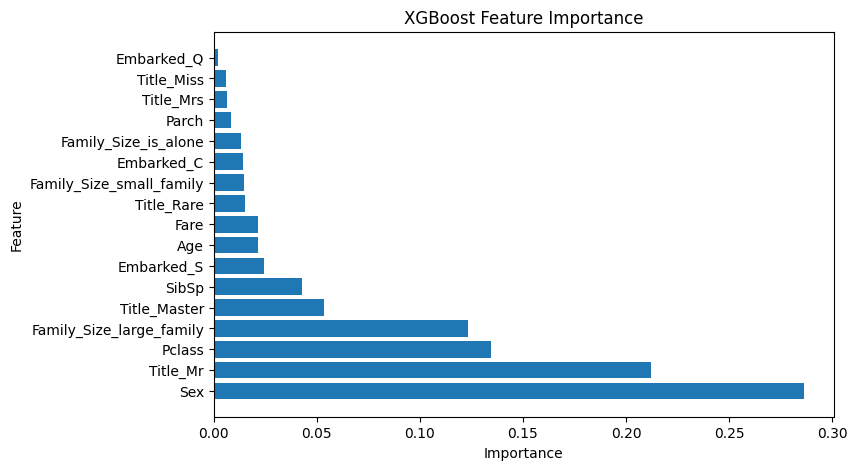

In [32]:
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()

## Conclusion

In this project, the Titanic dataset was analyzed using XGBoost and extensive feature engineering techniques.

Key preprocessing and feature engineering steps included:

- Handling missing values
- Removing uninformative features
- Creating and categorizing a Family_Size feature
- Extracting passenger titles from names
- Grouping rare titles
- Encoding categorical variables

After training and tuning an XGBoost classifier, the final model achieved a test accuracy of approximately 83.71%.

Feature importance analysis showed that passenger sex, title information, passenger class, and family size were among the most influential factors affecting survival predictions.

The final model was also used to generate Kaggle competition submissions.